# Imports

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import numpy.random as nr

from scipy import stats
from typing import Callable

# Definitions

In [2]:
def empirical_cdf(sample: list[float]):
    n = len(sample)

    @np.vectorize
    def Fn(x: float):
        p = 1/n * np.sum(sample <= x)
        return p

    return Fn


def KS_stat(sample: list[float], F: Callable):
    n = len(sample)
    Fn = empirical_cdf(sample)

    grid = np.arange(np.min(sample) - 1, np.max(sample) + 1, 0.01)
    stat = np.sqrt(n) * np.max(np.abs(Fn(grid) - F(grid)))

    return stat


def Brownian_bridge(t, seed=None):
    if seed is not None:
        nr.seed(seed)

    increments = np.diff(t)
    W = np.cumsum(np.sqrt(increments) * nr.normal(loc=0, scale=1, size=len(increments)))
    W = np.r_[0, W]

    B = W - W[-1] * t

    return B


def KS_rv(seed=None):
    if seed is not None:
        nr.seed(seed)

    grid = np.arange(0, 1, 10e-6)
    KS = np.max(np.abs(Brownian_bridge(grid)))

    return KS


def KS_cdf():
    sample = np.array([KS_rv() for _ in range(10000)])
    Fn = empirical_cdf(sample)

    return Fn

# Empirical cumulative distribution function

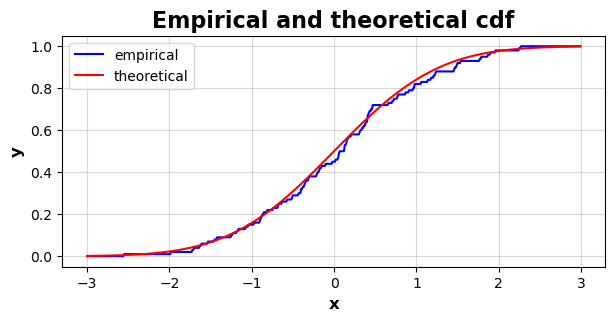

In [3]:
nr.seed(0)

n = 100
Fn = empirical_cdf(nr.normal(loc=0, scale=1, size=n))
F = stats.norm.cdf
grid = np.arange(-3, 3, 0.01)


plt.figure(figsize=(7, 3))
plt.plot(grid, Fn(grid), color="blue", label="empirical")
plt.plot(grid, F(grid), color="red", label="theoretical")
plt.grid(alpha=0.5)
plt.xlabel("x", fontdict={"size": 12, "weight": "bold"})
plt.ylabel("y", fontdict={"size": 12, "weight": "bold"})
plt.title("Empirical and theoretical cdf", fontdict={"size": 16, "weight": "bold"})
plt.legend()
plt.show()

# Kolmogorov-Smirnov distribution

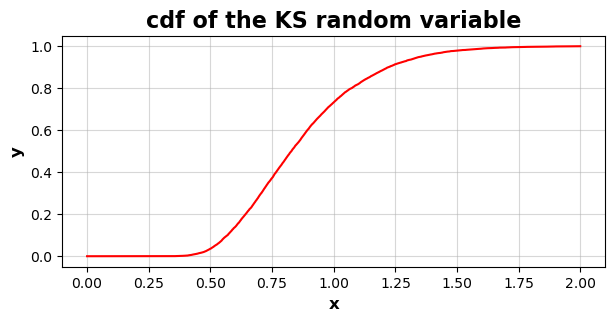

In [4]:
nr.seed(0)

F_KS = KS_cdf()
grid = np.arange(0, 2, 0.001)


plt.figure(figsize=(7, 3))
plt.plot(grid, F_KS(grid), color="red")
plt.grid(alpha=0.5)
plt.xlabel("x", fontdict={"size": 12, "weight": "bold"})
plt.ylabel("y", fontdict={"size": 12, "weight": "bold"})
plt.title("cdf of the KS random variable", fontdict={"size": 16, "weight": "bold"})
plt.show()

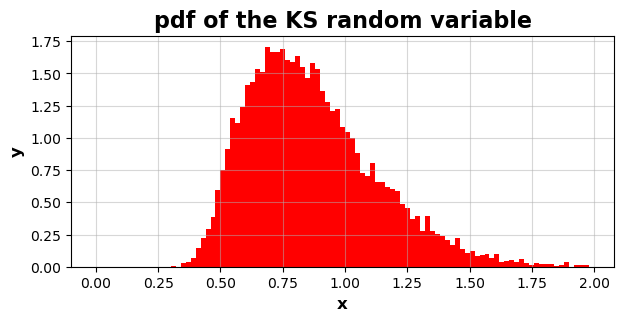

In [5]:
nr.seed(0)

KS_rvs = np.array([KS_rv() for _ in range(10000)])

plt.figure(figsize=(7, 3))
plt.hist(KS_rvs, bins=np.arange(0, 2, 0.02), density=True, color="red")
plt.grid(alpha=0.5)
plt.xlabel("x", fontdict={"size": 12, "weight": "bold"})
plt.ylabel("y", fontdict={"size": 12, "weight": "bold"})
plt.title("pdf of the KS random variable", fontdict={"size": 16, "weight": "bold"})
plt.show()

# Kolmogorov-Smirnov statistic

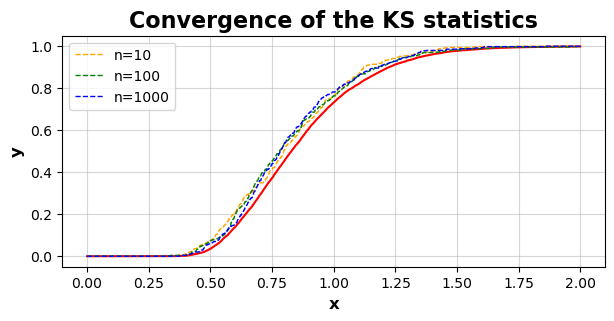

In [6]:
nr.seed(0)

colors = ["orange", "green", "blue"]

F_KS = KS_cdf()
grid = np.arange(0, 2, 0.001)
max_diffs = []


plt.figure(figsize=(7, 3))
plt.plot(grid, F_KS(grid), color="red")

for i, n in enumerate([10, 100, 1000]):
    sample = np.array([KS_stat(nr.normal(0, 1, n), stats.norm.cdf) for _ in range(500)])
    Fn = empirical_cdf(sample)
    plt.plot(grid, Fn(grid), color=colors[i], ls="--", lw=1, label=f"n={n}")

    max_diff = np.max(np.abs(Fn(grid) - F_KS(grid)))
    max_diffs.append(max_diff)

plt.grid(alpha=0.5)
plt.xlabel("x", fontdict={"size": 12, "weight": "bold"})
plt.ylabel("y", fontdict={"size": 12, "weight": "bold"})
plt.title("Convergence of the KS statistics", fontdict={"size": 16, "weight": "bold"})
plt.legend()
plt.show()

In [7]:
print("Maximum difference:")
for max_diff in max_diffs:
    print(max_diff)

Maximum difference:
0.08950000000000002
0.0952
0.08750000000000002
